In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


  LOAD DATASET



In [ ]:
file= pd.read_csv('/content/retail_sales_dataset.csv')
file.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
print("Dataset Shape :", file.shape)

Dataset Shape : (1000, 9)


In [ ]:
print("Dataset info :", file.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
Dataset info : None


In [ ]:
print("Dataset columns :", file.columns)

Dataset columns : Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')


In [ ]:
print("Dataset Describe :", file.describe())

Dataset Describe :        Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000


 DATA CLEANING

In [10]:
print("Dataset isnull.sum :",file.isnull().sum())

Dataset isnull.sum : Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [11]:
print("Dataset duplicated.sum :",  file.duplicated().sum())

Dataset duplicated.sum : 0


In [12]:
file.drop_duplicates(inplace=True)

DATATYPE ANALYSIS

In [14]:
print("Dataset Datatype :", file.dtypes)

Dataset Datatype : Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [16]:
file.select_dtypes(include='object').columns

Index(['Date', 'Customer ID', 'Gender', 'Product Category'], dtype='object')

Descriptive Statistics

In [17]:
print("Average Age:", file['Age'].mean())
print("Median Age:", file['Age'].median())
print("Minimum Age:", file['Age'].min())
print("Maximum Age:", file['Age'].max())

Average Age: 41.392
Median Age: 42.0
Minimum Age: 18
Maximum Age: 64


Customer Age Distribution

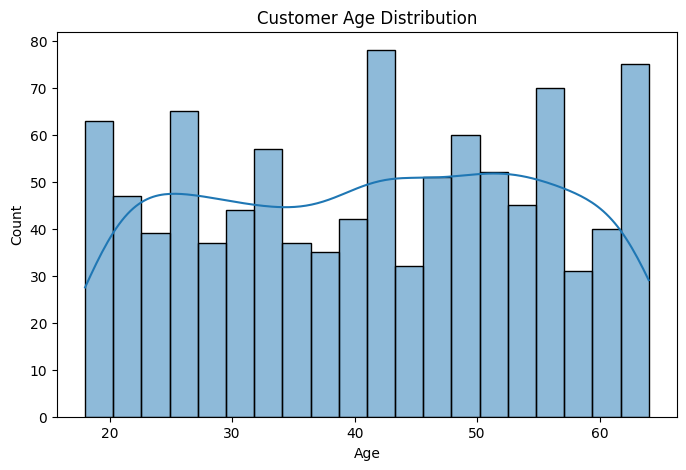

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(file['Age'], bins=20, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

Gender Distribution

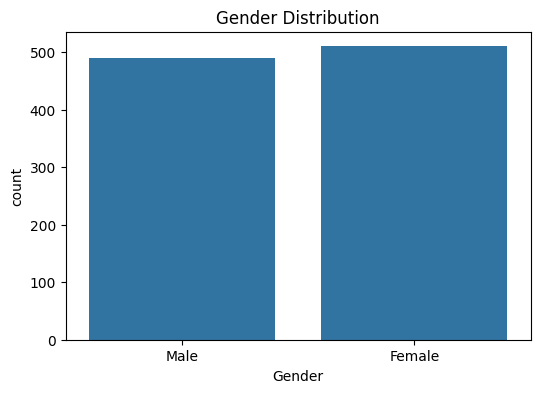

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=file)

plt.title("Gender Distribution")

plt.show()

Sales by Gender
(Total revenue comparision )

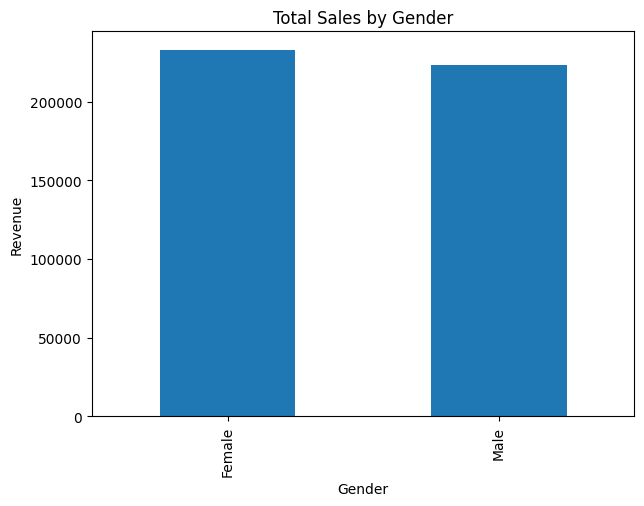

In [22]:
gender_sales = file.groupby('Gender')['Total Amount'].sum()

gender_sales

plt.figure(figsize=(7,5))

gender_sales.plot(kind='bar')

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")

plt.show()

Product Category Distribution

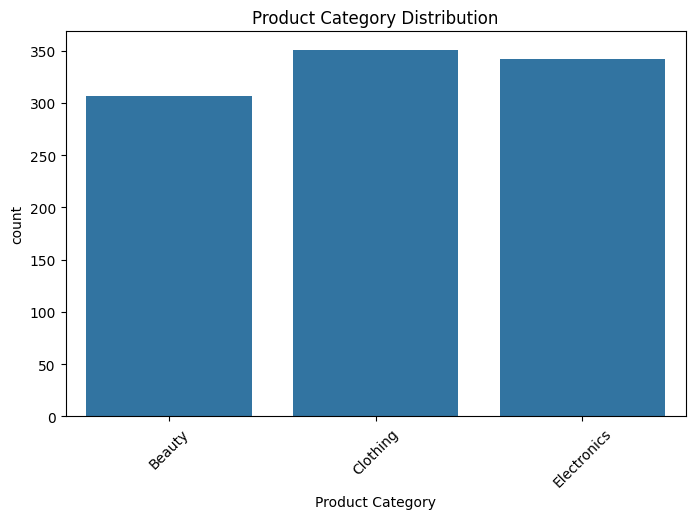

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Product Category',
    data=file
)

plt.title("Product Category Distribution")

plt.xticks(rotation=45)

plt.show()

Revenue by Product Category

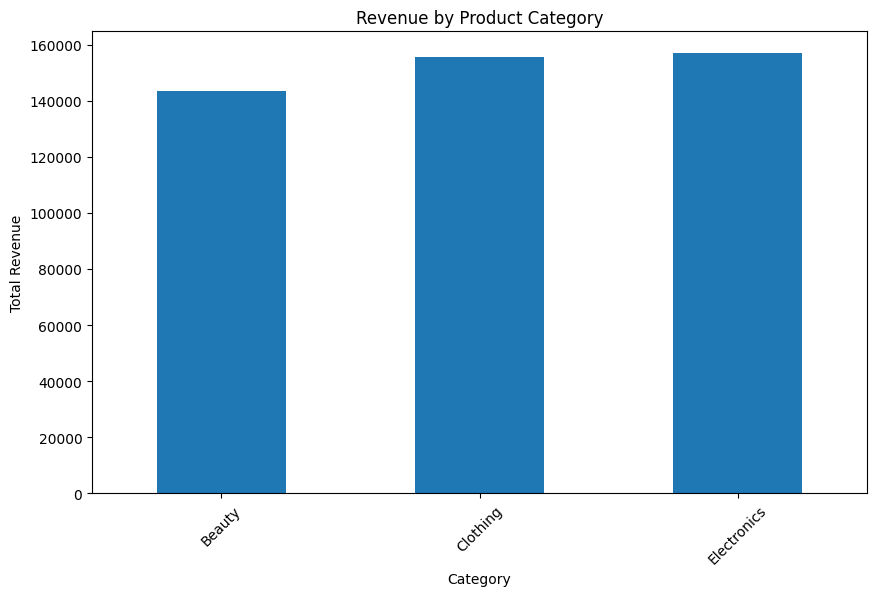

In [24]:
category_revenue = file.groupby(
    'Product Category'
)['Total Amount'].sum().sort_values()

plt.figure(figsize=(10,6))

category_revenue.plot(kind='bar')

plt.title("Revenue by Product Category")

plt.xlabel("Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

Total Revenue Calculation

In [25]:
total_revenue = file['Total Amount'].sum()

print("Total Revenue Generated:", total_revenue)

Total Revenue Generated: 456000


Average Transaction Value

In [26]:
average_transaction = file['Total Amount'].mean()

print(
    "Average Transaction Value:",
    average_transaction
)

Average Transaction Value: 456.0


Top 10 Highest Value Transactions

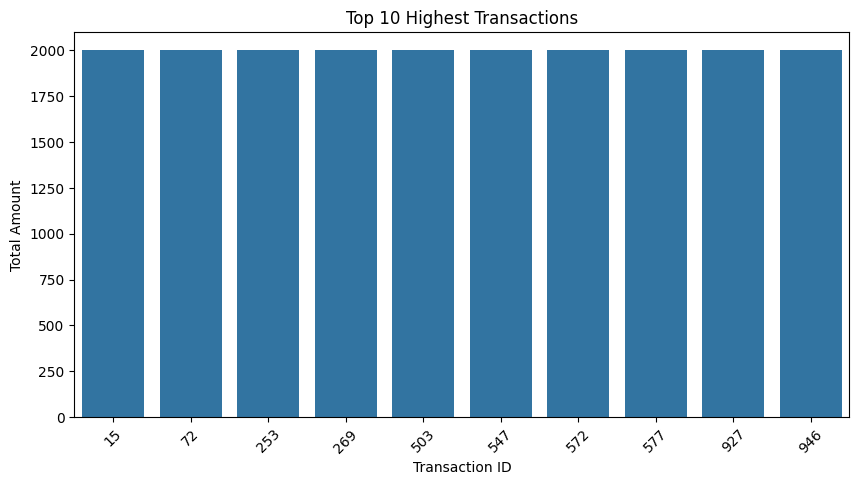

In [27]:
top_transactions = file.sort_values(
    by='Total Amount',
    ascending=False
).head(10)

top_transactions

plt.figure(figsize=(10,5))

sns.barplot(
    x='Transaction ID',
    y='Total Amount',
    data=top_transactions
)

plt.title("Top 10 Highest Transactions")

plt.xticks(rotation=45)

plt.show()

Quantity vs Total Amount Analysis

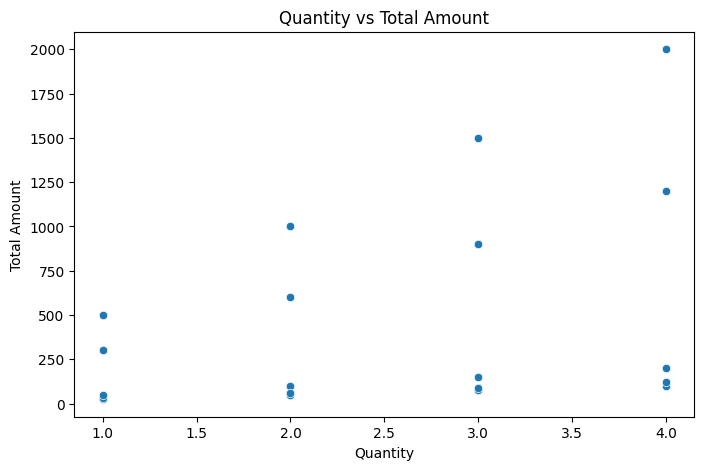

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Quantity',
    y='Total Amount',
    data=file
)

plt.title("Quantity vs Total Amount")

plt.show()

Outlier Detection

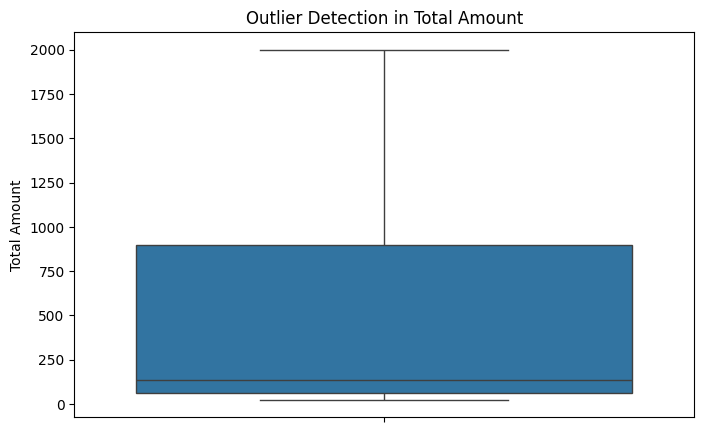

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=file['Total Amount']
)

plt.title("Outlier Detection in Total Amount")

plt.show()

Correlation Heatmap

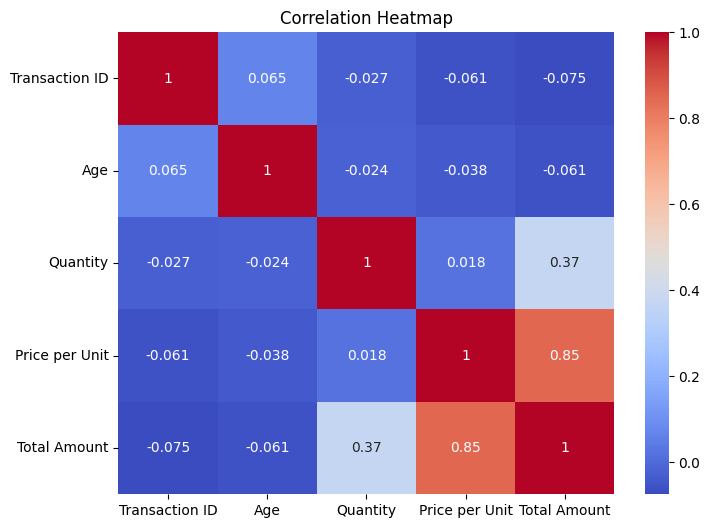

In [30]:
plt.figure(figsize=(8,6))

correlation = file.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()